In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
def parse_improvement_file(filename):
    """Parse improvement file and return (times, objectives) arrays."""
    times = []
    objectives = []
    
    try:
        with open(filename, 'r') as f:
            for line in f:
                line = line.strip()
                # Skip comments and empty lines
                if not line or line.startswith('#'):
                    continue
                
                parts = line.split()
                if len(parts) >= 2:
                    try:
                        time = float(parts[0])
                        obj = float(parts[1])
                        times.append(time)
                        objectives.append(obj)
                    except ValueError:
                        continue
    except FileNotFoundError:
        print(f"Warning: File {filename} not found, skipping...")
        return None, None
    except Exception as e:
        print(f"Error reading {filename}: {e}")
        return None, None
    
    if len(times) == 0:
        print(f"Warning: No data found in {filename}")
        return None, None
    
    return np.array(times), np.array(objectives)

In [36]:
def plot_subgraph(instance_name, base_obj, ax, yscale_limit=2., xscale_limit=900):
    pdbo_file = f"./results/pdbo/{instance_name}.txt"
    rots_file = f"./results/baseline/{instance_name}_rots_improvements.txt"
    bma_file = f"./results/baseline/{instance_name}_bma_improvements.txt"

    pdbo_time, pdbo_obj = parse_improvement_file(pdbo_file)
    rots_time, rots_obj = parse_improvement_file(rots_file)
    bma_time, bma_obj = parse_improvement_file(bma_file)
    
    pdbo_mask = pdbo_time <= xscale_limit
    rots_mask = rots_time <= xscale_limit
    bma_mask = bma_time <= xscale_limit

    pdbo_obj = pdbo_obj[pdbo_mask]
    rots_obj = rots_obj[rots_mask]
    bma_obj = bma_obj[bma_mask]

    # base_obj = min(bma_obj)

    pdbo_obj = np.minimum((pdbo_obj - base_obj) / base_obj, yscale_limit)
    rots_obj = np.minimum((rots_obj - base_obj) / base_obj, yscale_limit)
    bma_obj = np.minimum((bma_obj - base_obj) / base_obj, yscale_limit)

    pdbo_time = pdbo_time[pdbo_mask]
    rots_time = rots_time[rots_mask]
    bma_time = bma_time[bma_mask]
    
    
    colors = ["#6cb0a1", "#60a3c9", "#d8904c"]
    # linestyles = ['-', '--', '-.', ':']

    ax.plot(pdbo_time, pdbo_obj, label="PDBO", 
                color=colors[0], linewidth=2, marker='o', 
                markersize=3, markevery=max(1, len(pdbo_time)//50))

    ax.plot(rots_time, rots_obj, label="RoTS", 
                color=colors[1], linewidth=2, marker='o', 
                markersize=3, markevery=max(1, len(rots_time)//50))

    ax.plot(bma_time, bma_obj, label="BMA", 
                color=colors[2], linewidth=2, marker='o', 
                markersize=3, markevery=max(1, len(bma_time)//50))
    ax.set_xlabel('Time (s)', fontsize=12)
    
    # set y-tick to be percentages
    yticks = np.arange(0, yscale_limit+0.1, 0.25)
    yticklabels = [f"{int(y*100)}%" for y in yticks]
    ax.set_yticks(yticks)
    ax.set_yticklabels(yticklabels, fontsize=10)
    # ax.set_ylim(0.9, yscale_limit+0.1)
    ax.set_ylim(-0.1, yscale_limit+0.1)
    ax.set_xlim(-20, xscale_limit)
    # ax.set_ylabel('Normalized Objective', fontsize=12)
    ax.legend(loc='best', fontsize=10)
    ax.set_title(f'{instance_name}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

In [37]:
n = 125
xscale_limit = 900
yscale_limit = 1.5

bks = pd.read_csv('taillarde_labels.txt', sep=' ', header=None, index_col=0, names=['instance', 'label'])

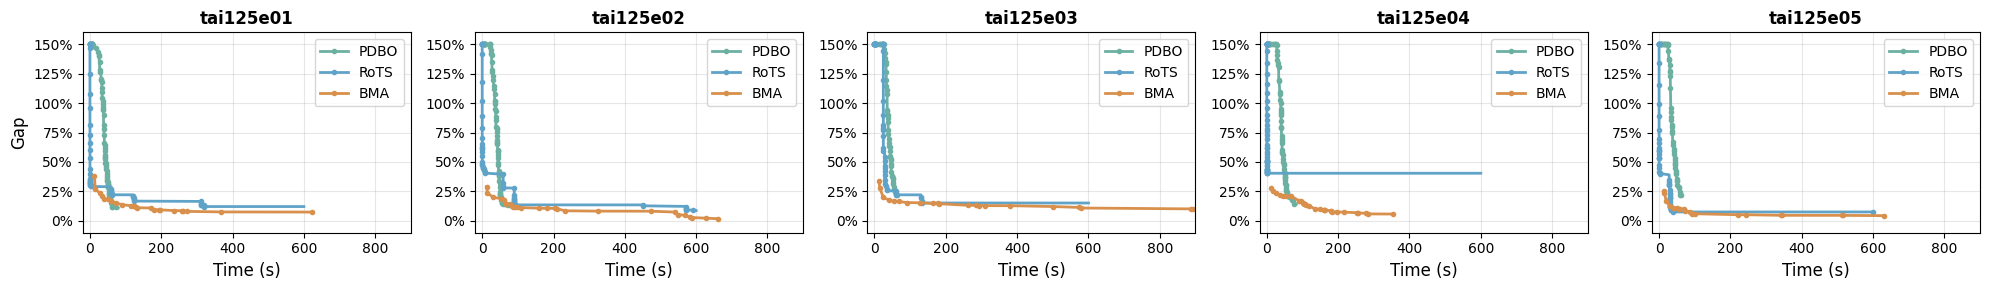

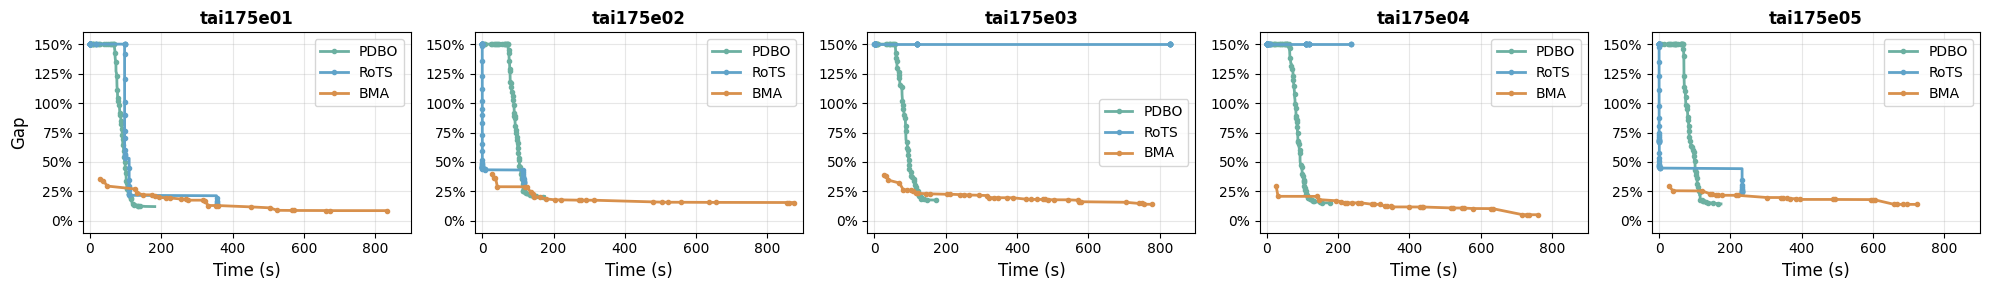

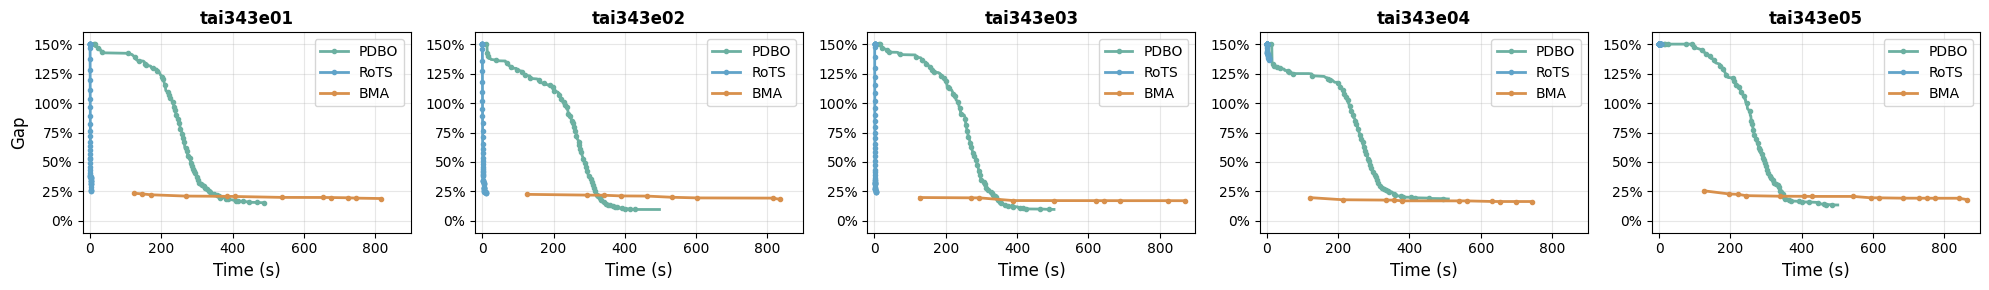

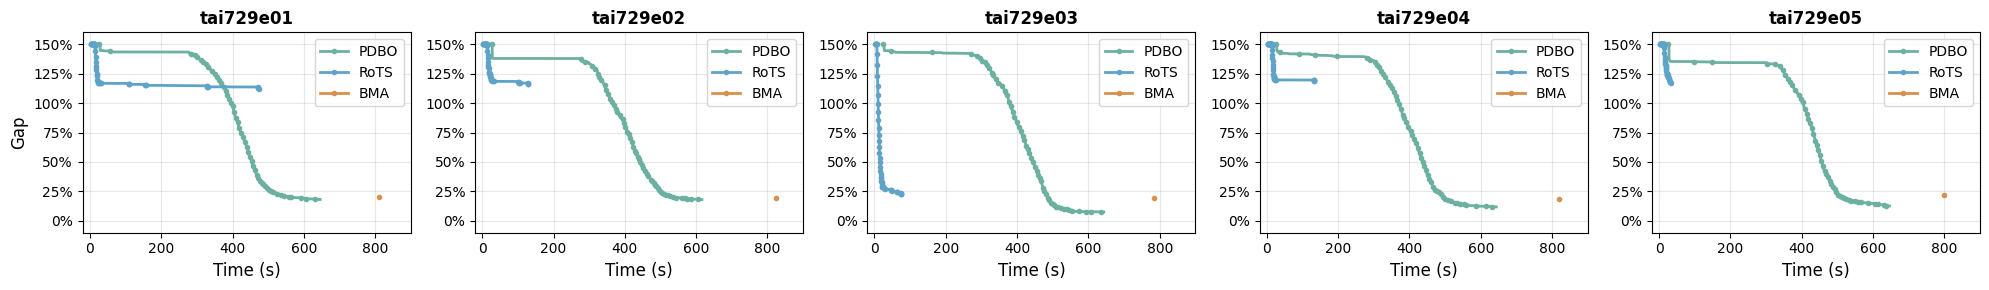

In [40]:
for n in [125, 175, 343, 729]:
    fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(20, 3))

    for i, ax in enumerate(axes):
        instance_name = f"tai{n}e0{i+1}"
        plot_subgraph(instance_name, bks.loc[instance_name].values, ax, yscale_limit=yscale_limit, xscale_limit=xscale_limit)
        if i == 0 :
            ax.set_ylabel('Gap', fontsize=12)
            

    plt.tight_layout()
    plt.savefig(f'comparison_tai{n}e.pdf', dpi=800, bbox_inches='tight')
    plt.show()

In [279]:
instance_name = "tai175e05"

pdbo_file = f"./results/pdbo/{instance_name}.txt"
rots_file = f"./results/baseline/{instance_name}_rots_improvements.txt"
bma_file = f"./results/baseline/{instance_name}_bma_improvements.txt"


pdbo_time, pdbo_obj = parse_improvement_file(pdbo_file)
rots_time, rots_obj = parse_improvement_file(rots_file)
bma_time, bma_obj = parse_improvement_file(bma_file)

In [ ]:
yscale_limit = 2.5
xscale_limit = 900

pdbo_mask = pdbo_time <= xscale_limit
rots_mask = rots_time <= xscale_limit
bma_mask = bma_time <= xscale_limit

pdbo_obj = pdbo_obj[pdbo_mask]
rots_obj = rots_obj[rots_mask]
bma_obj = bma_obj[bma_mask]

base_obj = min(bma_obj)

pdbo_obj = np.minimum(pdbo_obj / base_obj, yscale_limit)
rots_obj = np.minimum(rots_obj / base_obj, yscale_limit)
bma_obj = np.minimum(bma_obj / base_obj, yscale_limit)

pdbo_time = pdbo_time[pdbo_mask]
rots_time = rots_time[rots_mask]
bma_time = bma_time[bma_mask]

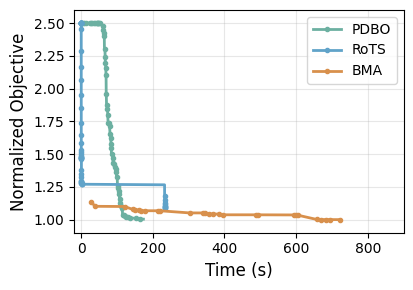

In [276]:
plt.figure(figsize=(4, 3))
colors = ["#6cb0a1", "#60a3c9", "#d8904c"]
# linestyles = ['-', '--', '-.', ':']

plt.plot(pdbo_time, pdbo_obj, label="PDBO", 
            color=colors[0], linewidth=2, marker='o', 
            markersize=3, markevery=max(1, len(pdbo_time)//50))

plt.plot(rots_time, rots_obj, label="RoTS", 
            color=colors[1], linewidth=2, marker='o', 
            markersize=3, markevery=max(1, len(rots_time)//50))

plt.plot(bma_time, bma_obj, label="BMA", 
            color=colors[2], linewidth=2, marker='o', 
            markersize=3, markevery=max(1, len(bma_time)//50))
plt.xlabel('Time (s)', fontsize=12)
plt.tight_layout()
plt.ylim(0.9, 2.6)
plt.xlim(-20, 900)
plt.ylabel('Normalized Objective', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# plot three methods side by side for comparison
